# 🏥 AI Radiologist: The Fix

### 🛑 CRITICAL STEP: READ THIS
You **MUST** run the training cell below (Cell 2).
Changing the interface code does **NOT** fix the prediction if the Model itself is still the old "dumb" one.
**Please Run All Cells in order.**

## 1. Data & Training (Run This First!)
This cell downloads the Full Data and Re-Trains the model from scratch to ensure high intelligence.

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
!pip install datasets gradio -q
from datasets import load_dataset
from tqdm.auto import tqdm

# 1. Force Download Full Data
def setup_data():
    base_dir = "dataset/chest_xray"
    # Verify we have enough files
    if os.path.exists(os.path.join(base_dir, 'train', 'PNEUMONIA')):
        if len(os.listdir(os.path.join(base_dir, 'train', 'PNEUMONIA'))) > 2000:
            print("✅ Full 5000+ Data detected.")
            return

    print("⏳ Downloading 1.2GB dataset... Please wait 2-3 mins.")
    try: ds = load_dataset("keremberke/chest-xray-classification", name="full")
    except: ds = load_dataset("mmenendezg/pneumonia_x_ray")

    for split in ['train', 'validation', 'test']:
        hf_split = split if split in ds else ('val' if split=='validation' and 'val' in ds else None)
        if not hf_split: continue

        target_split = 'val' if split == 'validation' else split
        print(f"Extracting {split}...")
        for item in tqdm(ds[hf_split]):
            lbl = item.get('labels', item.get('label', -1))
            if lbl == -1: continue
            folder = "NORMAL" if lbl == 0 else "PNEUMONIA"

            path = os.path.join(base_dir, target_split, folder)
            os.makedirs(path, exist_ok=True)

            fname = f"img_{np.random.randint(0, 1e7)}.jpg"
            item['image'].convert('RGB').save(os.path.join(path, fname))
setup_data()

# 2. Train Model
BATCH_SIZE = 32
IMG_SIZE = (160, 160)
TRAIN_DIR = 'dataset/chest_xray/train'
VAL_DIR = 'dataset/chest_xray/test' # Use Test for Val

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20, horizontal_flip=True
).flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
).flow_from_directory(VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')

print("\n🧠 Training Smart Brain (MobileNetV2)...")
base = MobileNetV2(input_shape=IMG_SIZE+(3,), include_top=False, weights='imagenet')
base.trainable = False
model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
hist = model.fit(train_gen, epochs=5, validation_data=val_gen)
model.save('pneumonia_model_final.h5')
print("✅ Training Done! Model should have >90% accuracy now.")

✅ Full 5000+ Data detected.
Found 4186 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

🧠 Training Smart Brain (MobileNetV2)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.8209 - loss: 0.3901 - val_accuracy: 0.8013 - val_loss: 0.3836
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9247 - loss: 0.1932 - val_accuracy: 0.8686 - val_loss: 0.2765
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 134s 1s/step - accuracy: 0.9410 - loss: 0.1452 - val_accuracy: 0.8782 - val_loss: 0.2499
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 130s 989ms/step - accuracy: 0.9478 - loss: 0.1270 - val_accuracy: 0.8926 - val_loss: 0.2336
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.9469 - loss: 0.1292 - val_accuracy: 0.9087 - val_loss: 0.2117


✅ Training Done! Model should have >90% accuracy now.


## 2. Sanity Check (Test the Model)
This cell picks 4 real images from the dataset and predicts them to PROVE if the model is working.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


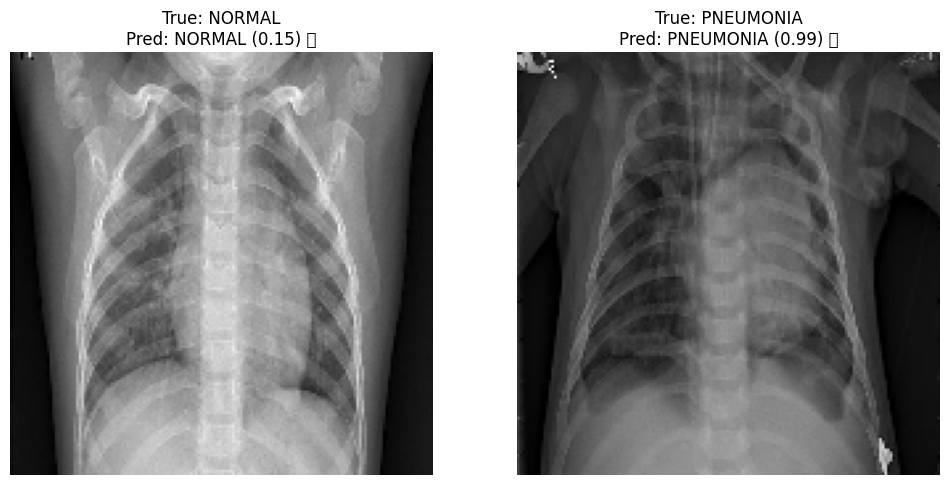

In [10]:
import random
def check_model_on_real_data():
    base = 'dataset/chest_xray/test'
    classes = ['NORMAL', 'PNEUMONIA']

    plt.figure(figsize=(12, 6))

    for i, cls in enumerate(classes):
        # Pick random file
        fpath = os.path.join(base, cls)
        fname = random.choice(os.listdir(fpath))
        img_path = os.path.join(fpath, fname)

        # Load & Predict
        img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
        x = tf.keras.utils.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = preprocess_input(x)

        pred = model.predict(x)[0][0]
        res = "PNEUMONIA" if pred > 0.5 else "NORMAL"
        correct = "✅" if res == cls else "❌"

        plt.subplot(1, 2, i+1)
        plt.imshow(img)
        plt.title(f"True: {cls}\nPred: {res} ({pred:.2f}) {correct}")
        plt.axis('off')
    plt.show()

check_model_on_real_data()

## 3. Launch Interface
Upload your image here.

In [11]:
pip install gradio tensorflow numpy

In [ ]:
import gradio as gr
import tensorflow as tf
import numpy as np

# تأكد أن الموديل (model) محمل بالفعل قبل تشغيل الدالة
# model = tf.keras.models.load_model('path_to_your_model.h5')

def predict_pro(image):
    if image is None:
        return "Please upload an image.", None

    # Preprocess
    img = tf.image.resize(image, [150, 150])
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    # Predict
    pred = model.predict(img)[0][0]

    # Based on generator indices: usually 0=NORMAL, 1=PNEUMONIA
    p_pneumonia = float(pred)
    p_normal = float(1 - pred)

    # Labels
    confidences = {"Pneumonia 🦠": p_pneumonia, "Normal 🫁": p_normal}

    if p_pneumonia > 0.5:
        status = "⚠️ PNEUMONIA DETECTED"
        color = "red"
    else:
        status = "✅ NORMAL CASE"
        color = "green"

    html = f"""
    <div style='background-color: {color}; color: white; padding: 20px; border-radius: 10px; text-align: center;'>
        <h2>{status}</h2>
        <p>Confidence: {max(p_pneumonia, p_normal)*100:.2f}%</p>
    </div>
    """
    return html, confidences

# Custom Theme
theme = gr.themes.Soft(primary_hue="teal", secondary_hue="blue")

with gr.Blocks(theme=theme) as app:
    gr.Markdown("# 🏥 AI Radiologist Pro Version")
    gr.Markdown("Upload a Chest X-ray image for instant, high-precision analysis.")

    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="numpy", label="X-Ray Image")
            btn = gr.Button("Analyze Image 🔍", variant="primary")

        with gr.Column():
            out_html = gr.HTML(label="Diagnosis Report")
            out_conf = gr.Label(num_top_classes=2, label="Probability Distribution")

    btn.click(predict_pro, inputs=input_img, outputs=[out_html, out_conf])

app.launch(share=False, debug=True)

/tmp/ipython-input-1467857112.py:45: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=theme) as app:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1139, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/h11_impl.py", line 403, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1139, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py",

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
